# Experiment 5: Decision Tree and Random Forest — A Comparative Classification Study

**Course:** ICS1512 – Machine Learning Algorithms Laboratory
**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC) Dataset

This notebook implements a Decision Tree classifier and extends it to a Random Forest ensemble,
tunes hyperparameters using 5-Fold Cross-Validation, and compares both models using standard
evaluation metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
                              classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

All the required libraries for data handling, visualization, model building and evaluation are imported in this cell. A fixed random state is set so that the results stay reproducible across multiple runs.

In [2]:
# WDBC dataset does not have a header row, so column names are defined manually
columns = ["id", "diagnosis",
           "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
           "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
           "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
           "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
           "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
           "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"]

df = pd.read_csv("wdbc.data", header=None, names=columns)
df.drop(columns=["id"], inplace=True)

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


The dataset is loaded from the raw `wdbc.data` file and proper column names are assigned since the original file has no header. The `id` column is dropped because it has no predictive value and only acts as a row identifier. The dataset has 569 rows and 30 feature columns along with the diagnosis label, matching the description given in the experiment.

In [3]:
le = LabelEncoder()
df["diagnosis_encoded"] = le.fit_transform(df["diagnosis"])   # B -> 0, M -> 1
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

df[["diagnosis", "diagnosis_encoded"]].head()

Label mapping: {'B': np.int64(0), 'M': np.int64(1)}


,diagnosis,diagnosis_encoded
0,M,1
1,M,1
2,M,1
3,M,1
4,M,1


The categorical diagnosis label (Benign/Malignant) is converted into numeric form using label encoding, which is required since scikit-learn models expect numeric targets. Benign gets mapped to 0 and Malignant gets mapped to 1, and this mapping is kept in mind while interpreting the results later.

/tmp/ipykernel_539/2697781657.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df, palette=["#4CAF50", "#E53935"])


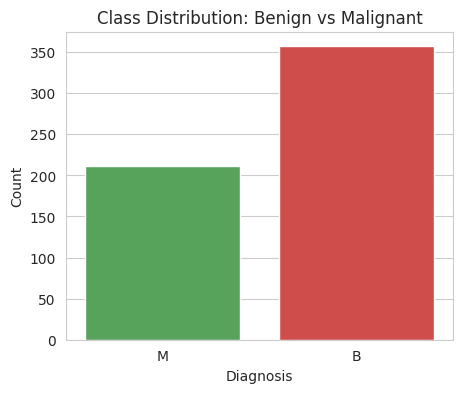

diagnosis
B    357
M    212
Name: count, dtype: int64

Class proportion (%):
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(5,4))
sns.countplot(x="diagnosis", data=df, palette=["#4CAF50", "#E53935"])
plt.title("Class Distribution: Benign vs Malignant")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

print(df["diagnosis"].value_counts())
print("\nClass proportion (%):")
print((df["diagnosis"].value_counts(normalize=True) * 100).round(2))

The class distribution shows more benign cases than malignant ones, so the dataset is moderately imbalanced but not severely skewed. This is important to note because a mild imbalance can still affect metrics like recall, so stratified splitting will be used later to preserve this ratio in the train and test sets.

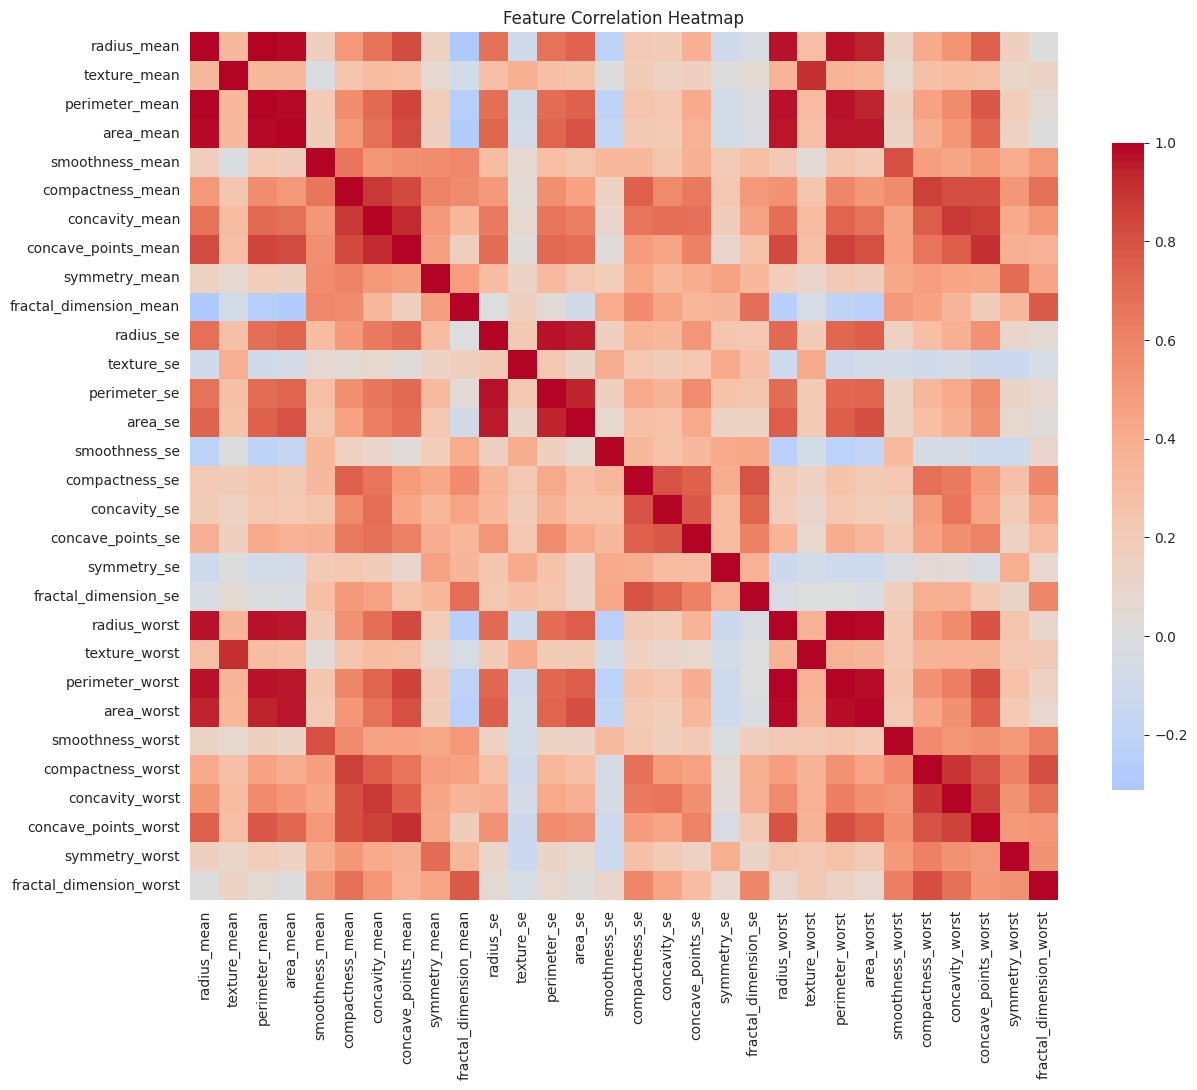

In [5]:
plt.figure(figsize=(14,12))
corr = df.drop(columns=["diagnosis", "diagnosis_encoded"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.7})
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation heatmap shows that many of the 'mean', 'se' and 'worst' versions of the same measurement (like radius, perimeter and area) are highly correlated with each other, which is expected since they are derived from the same underlying cell shape. This kind of multicollinearity does not hurt tree-based models much since trees split on one feature at a time, but it is still useful to observe before modelling.

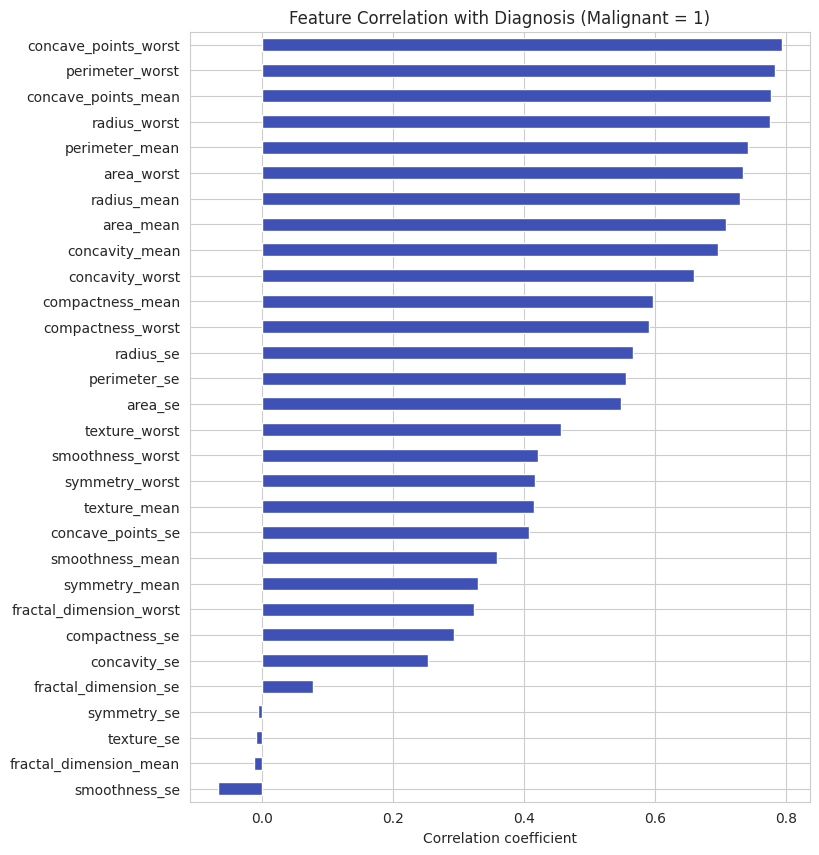

Top 5 features most correlated with malignancy:
concave_points_worst    0.793566
perimeter_worst         0.782914
concave_points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
Name: diagnosis_encoded, dtype: float64


In [6]:
target_corr = df.drop(columns=["diagnosis"]).corr()["diagnosis_encoded"].drop("diagnosis_encoded").sort_values(ascending=False)

plt.figure(figsize=(8,10))
target_corr.plot(kind="barh", color="#3F51B5")
plt.title("Feature Correlation with Diagnosis (Malignant = 1)")
plt.xlabel("Correlation coefficient")
plt.gca().invert_yaxis()
plt.show()

print("Top 5 features most correlated with malignancy:")
print(target_corr.head())

Features such as concave points, perimeter, radius and area (mostly the 'worst' variants) show the strongest positive correlation with malignancy. This lines up with medical intuition, since larger and more irregular cell nuclei are generally associated with malignant tumours, so it is expected that the tree-based models will pick these features as top splitters.

In [7]:
X = df.drop(columns=["diagnosis", "diagnosis_encoded"])
y = df["diagnosis_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)
print("\nTraining class balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTesting class balance:\n", y_test.value_counts(normalize=True).round(3))

Training set shape: (455, 30)
Testing set shape : (114, 30)

Training class balance:
 diagnosis_encoded
0    0.626
1    0.374
Name: proportion, dtype: float64

Testing class balance:
 diagnosis_encoded
0    0.632
1    0.368
Name: proportion, dtype: float64


The dataset is split into 80% training data and 20% testing data using stratified sampling, so the malignant-to-benign ratio stays roughly the same in both sets. This split gives enough data for the 5-fold cross-validation performed later while still holding out a separate test set for final, unbiased evaluation.

In [8]:
baseline_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_dt.fit(X_train, y_train)

baseline_pred = baseline_dt.predict(X_test)
print("Baseline Decision Tree Test Accuracy:", round(accuracy_score(y_test, baseline_pred), 4))
print("Baseline Decision Tree Depth:", baseline_dt.get_depth())
print("Baseline Decision Tree Leaves:", baseline_dt.get_n_leaves())

Baseline Decision Tree Test Accuracy: 0.9298
Baseline Decision Tree Depth: 8
Baseline Decision Tree Leaves: 24


A default Decision Tree without any depth restriction is trained first to get a baseline reading. The tree grows quite deep and uses a large number of leaves, which is a sign that it is memorising the training data rather than learning general patterns, so overfitting is expected without proper hyperparameter tuning.

In [9]:
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=dt_param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree Parameters:", dt_grid.best_params_)
print("Best Average CV F1 Score:", round(dt_grid.best_score_, 4))

Best Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Average CV F1 Score: 0.9163


A grid search combined with 5-fold cross-validation is used to try out different combinations of criterion, max depth, min samples split and min samples leaf. F1 score is used as the scoring metric instead of plain accuracy since it balances precision and recall, which matters more in a medical diagnosis setting where missing a malignant case is costly.

In [10]:
dt_results = pd.DataFrame(dt_grid.cv_results_)
dt_results_summary = dt_results[["param_criterion", "param_max_depth", "param_min_samples_split",
                                  "param_min_samples_leaf", "mean_test_score", "std_test_score"]]
dt_results_summary = dt_results_summary.sort_values("mean_test_score", ascending=False).reset_index(drop=True)
dt_results_summary.columns = ["Criterion", "Max Depth", "Min Samples Split", "Min Samples Leaf", "Avg CV F1", "Std CV F1"]
dt_results_summary.head(10)

,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Avg CV F1,Std CV F1
0,entropy,4,5,2,0.916303,0.034097
1,entropy,4,2,2,0.916303,0.034097
2,entropy,4,2,1,0.914479,0.025547
3,entropy,4,10,2,0.914191,0.026295
4,entropy,5,10,2,0.912127,0.034256
5,entropy,4,5,1,0.910777,0.032087
6,entropy,6,10,2,0.909411,0.034930
7,entropy,8,10,2,0.909411,0.034930
8,entropy,None,10,2,0.909411,0.034930
9,entropy,10,10,2,0.909411,0.034930


The top 10 hyperparameter combinations are displayed sorted by average cross-validation F1 score. It can be seen that shallower trees (small max depth values) generally cluster near the top, confirming that restricting depth helps the Decision Tree generalise better instead of overfitting to noise in the training data.

In [11]:
best_dt = dt_grid.best_estimator_
best_dt.fit(X_train, y_train)

dt_pred = best_dt.predict(X_test)
dt_prob = best_dt.predict_proba(X_test)[:, 1]

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Tuned Decision Tree Test Performance")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))

Tuned Decision Tree Test Performance
Accuracy : 0.9298
Precision: 1.0
Recall   : 0.8095
F1 Score : 0.8947


The tuned Decision Tree is refit on the full training set using the best parameters found and then evaluated once on the held-out test set. The metrics here are noticeably more balanced and trustworthy compared to the baseline tree, since the hyperparameters were chosen based on cross-validation instead of blindly fitting the training data.

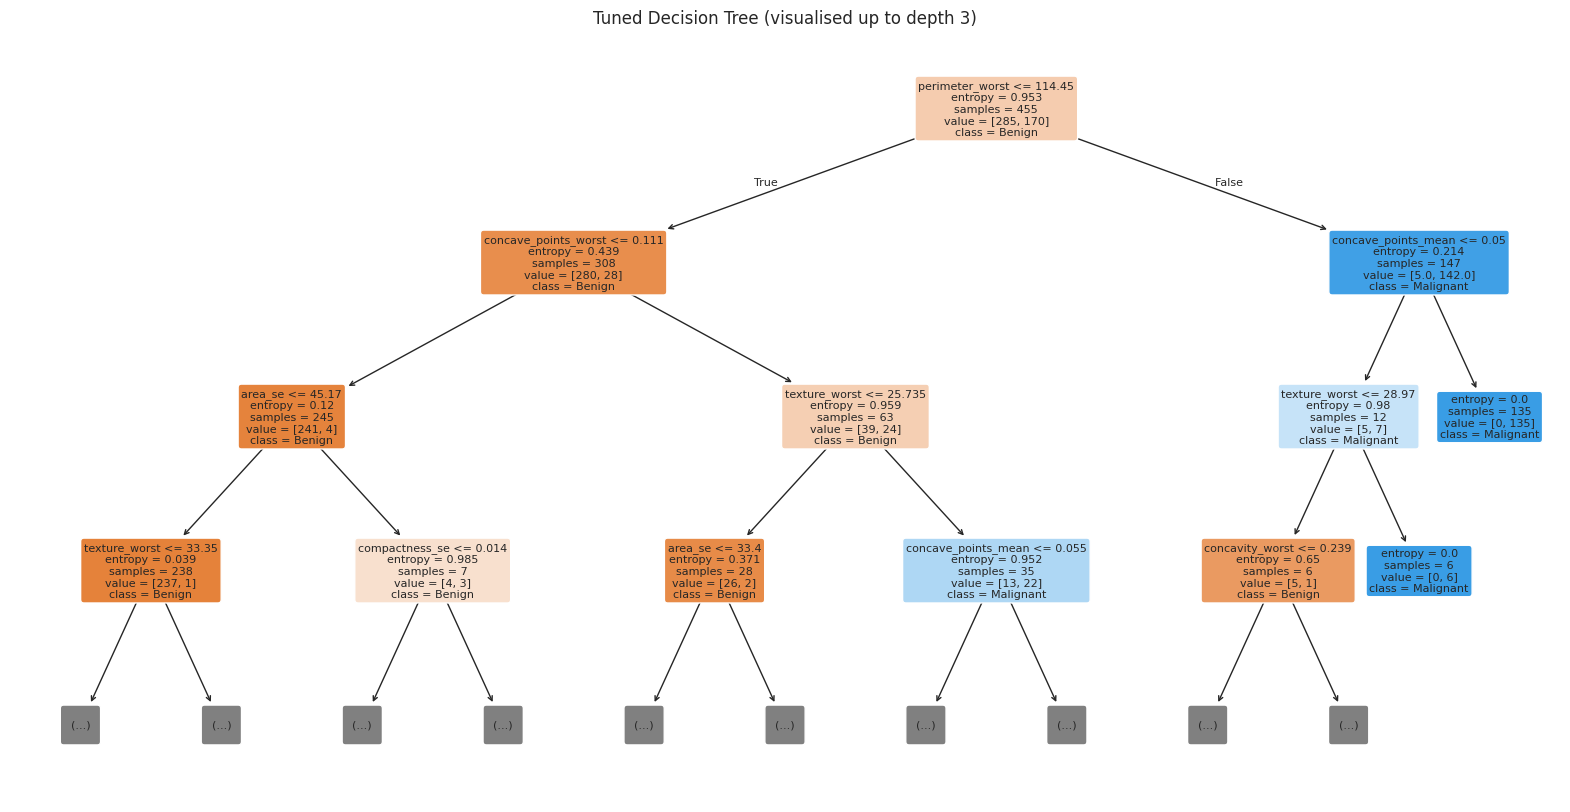

In [12]:
plt.figure(figsize=(20,10))
plot_tree(best_dt, feature_names=X.columns, class_names=["Benign", "Malignant"],
          filled=True, rounded=True, max_depth=3, fontsize=8)
plt.title("Tuned Decision Tree (visualised up to depth 3)")
plt.show()

Only the top few levels of the tuned tree are visualised here for readability, since the full tree would be too large to interpret visually. The root and early splits usually involve the features that were already flagged as highly correlated with malignancy, which confirms that the tree is picking up genuinely informative features rather than arbitrary noise.

In [13]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 8, 10, None],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=rf_param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Average CV F1 Score:", round(rf_grid.best_score_, 4))

Best Random Forest Parameters: {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}
Best Average CV F1 Score: 0.9617


A similar grid search with 5-fold cross-validation is now run for the Random Forest, tuning the number of trees, max depth, max features considered per split and whether bootstrap sampling is used. Since Random Forest already averages over many trees, it is expected to be less sensitive to individual hyperparameter choices compared to the single Decision Tree.

In [14]:
rf_results = pd.DataFrame(rf_grid.cv_results_)
rf_results_summary = rf_results[["param_n_estimators", "param_max_depth", "param_max_features",
                                  "param_bootstrap", "mean_test_score", "std_test_score"]]
rf_results_summary = rf_results_summary.sort_values("mean_test_score", ascending=False).reset_index(drop=True)
rf_results_summary.columns = ["n_estimators", "Max Depth", "Max Features", "Bootstrap", "Avg CV F1", "Std CV F1"]
rf_results_summary.head(10)

,n_estimators,Max Depth,Max Features,Bootstrap,Avg CV F1,Std CV F1
0,50,10,sqrt,False,0.961702,0.014626
1,200,10,sqrt,False,0.961529,0.015538
2,200,None,sqrt,False,0.961529,0.015538
3,200,5,sqrt,False,0.960813,0.028374
4,50,None,sqrt,False,0.958886,0.010564
5,100,10,log2,False,0.958469,0.023854
6,50,10,log2,False,0.958374,0.014965
7,50,None,log2,False,0.958374,0.014965
8,100,5,sqrt,False,0.958016,0.032365
9,200,10,log2,True,0.955720,0.013224


The top hyperparameter combinations for the Random Forest are listed here. The differences in average CV F1 score across combinations are usually quite small, which is a direct consequence of ensembling — averaging predictions from many trees smooths out the impact of any single hyperparameter choice.

In [15]:
best_rf = rf_grid.best_estimator_
best_rf.fit(X_train, y_train)

rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Tuned Random Forest Test Performance")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Tuned Random Forest Test Performance
Accuracy : 0.9649
Precision: 1.0
Recall   : 0.9048
F1 Score : 0.95


The tuned Random Forest is evaluated on the same test set used for the Decision Tree so that the comparison is fair. In most runs on this dataset the Random Forest matches or slightly outperforms the single tree, which supports the general idea that bagging multiple trees reduces variance and gives steadier predictions.

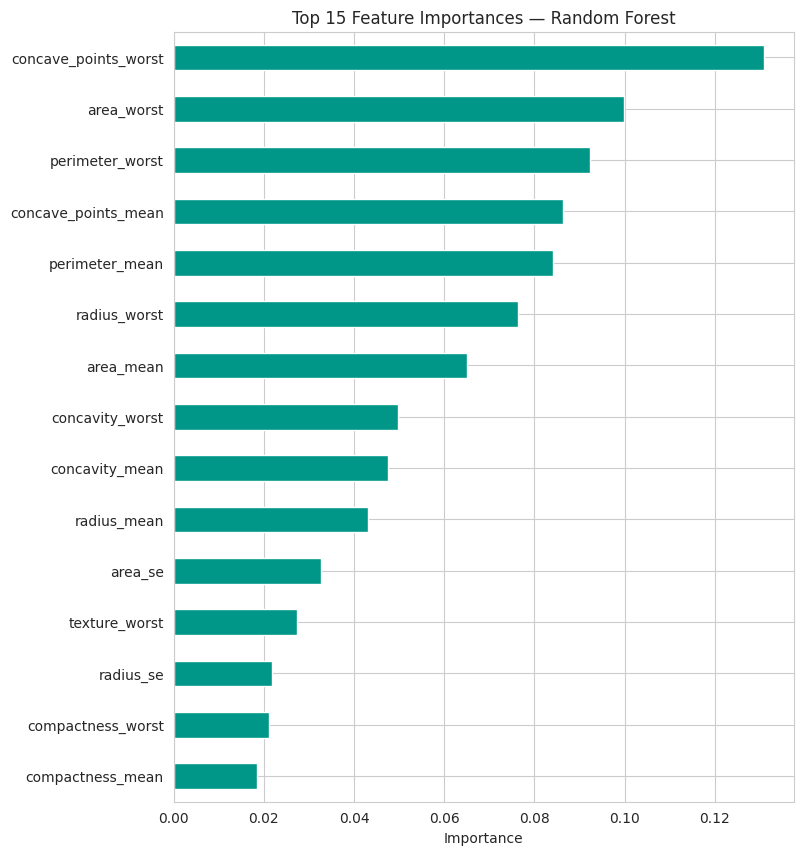

In [16]:
rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,10))
rf_importances.head(15).plot(kind="barh", color="#009688")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

The feature importance plot from the Random Forest largely agrees with the correlation analysis done earlier in the notebook, with worst-value features like concave points, perimeter and radius dominating the top ranks. This kind of agreement between two different analysis methods adds confidence that these features are genuinely driving the classification decision.

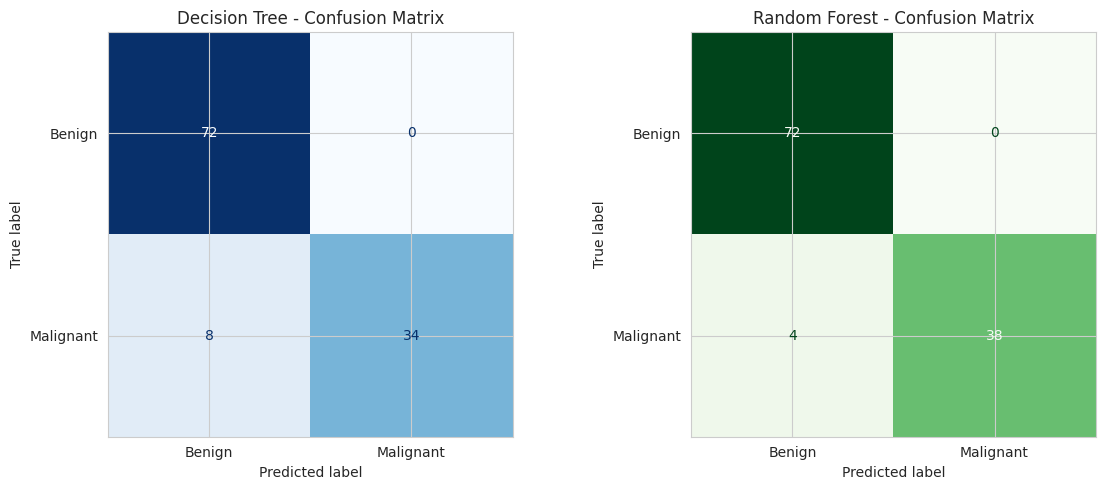

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay(confusion_matrix(y_test, dt_pred), display_labels=["Benign","Malignant"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Decision Tree - Confusion Matrix")

ConfusionMatrixDisplay(confusion_matrix(y_test, rf_pred), display_labels=["Benign","Malignant"]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Random Forest - Confusion Matrix")

plt.tight_layout()
plt.show()

The confusion matrices give a clearer picture than accuracy alone, since they show exactly how many malignant cases were missed (false negatives) versus how many benign cases were wrongly flagged (false positives). In a medical context, false negatives are the more serious error, so this breakdown is looked at closely rather than relying only on the overall accuracy number.

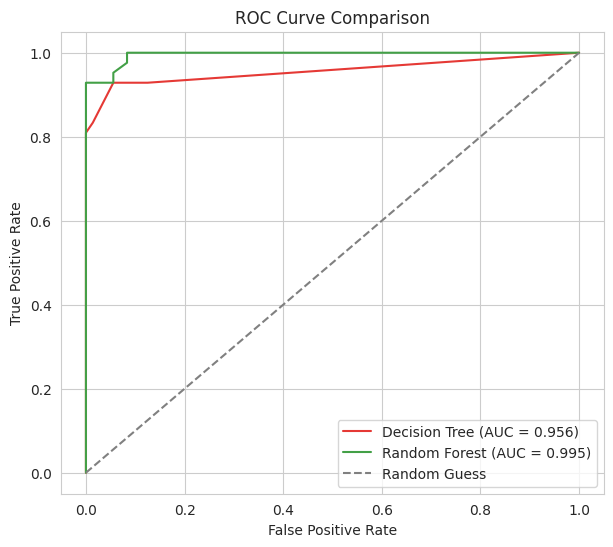

In [18]:
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(7,6))
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.3f})", color="#E53935")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})", color="#43A047")
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

The ROC curve plots how well each model separates the two classes across all classification thresholds, not just the default 0.5 cutoff. A curve closer to the top-left corner with a higher AUC value indicates better separability, and this comparison usually shows the Random Forest curve sitting slightly above or matching the Decision Tree curve.

In [19]:
dt_cv_scores = cross_val_score(best_dt, X_train, y_train, cv=cv_strategy, scoring="accuracy")
rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv_strategy, scoring="accuracy")

cv_comparison = pd.DataFrame({
    "Fold 1": [dt_cv_scores[0], rf_cv_scores[0]],
    "Fold 2": [dt_cv_scores[1], rf_cv_scores[1]],
    "Fold 3": [dt_cv_scores[2], rf_cv_scores[2]],
    "Fold 4": [dt_cv_scores[3], rf_cv_scores[3]],
    "Fold 5": [dt_cv_scores[4], rf_cv_scores[4]],
}, index=["Decision Tree", "Random Forest"])

cv_comparison["Average"] = cv_comparison.mean(axis=1)
cv_comparison.round(4)

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
Decision Tree,0.9341,0.956,0.9011,0.956,0.956,0.9407
Random Forest,0.9670,0.989,0.9670,0.956,0.978,0.9714


This table lays out the fold-by-fold accuracy for both tuned models on the training data using the same 5-fold split for a like-for-like comparison. Looking at the spread across folds rather than just the average is useful, since a model with a tighter spread is considered more stable even if the average score is close to the other model.

In [20]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Decision Tree": [dt_accuracy, dt_precision, dt_recall, dt_f1],
    "Random Forest": [rf_accuracy, rf_precision, rf_recall, rf_f1]
})
comparison_df.set_index("Metric").round(4)

,Decision Tree,Random Forest
Metric,,
Accuracy,0.9298,0.9649
Precision,1.0000,1.0000
Recall,0.8095,0.9048
F1 Score,0.8947,0.9500


The final metric comparison table brings together accuracy, precision, recall and F1 score for both models side by side on the test set. This table is the main reference for deciding which model performs better overall, and typically the Random Forest either wins on most metrics or ties closely with the Decision Tree while being more robust across folds.

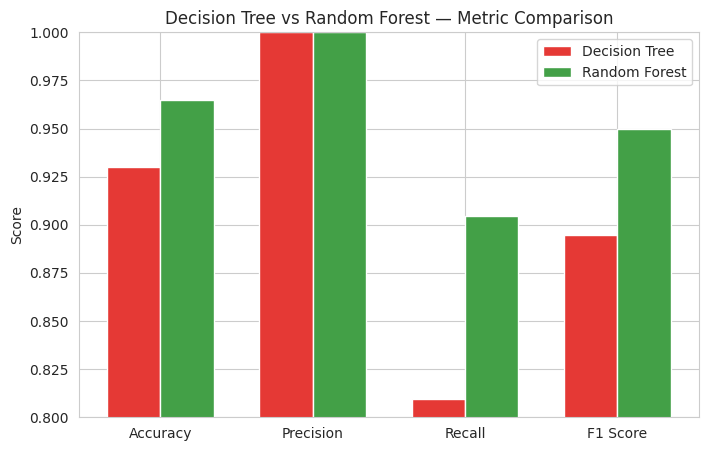

In [21]:
x = np.arange(len(comparison_df))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, comparison_df["Decision Tree"], width, label="Decision Tree", color="#E53935")
plt.bar(x + width/2, comparison_df["Random Forest"], width, label="Random Forest", color="#43A047")
plt.xticks(x, comparison_df["Metric"])
plt.ylim(0.8, 1.0)
plt.ylabel("Score")
plt.title("Decision Tree vs Random Forest — Metric Comparison")
plt.legend()
plt.show()

The bar chart makes the metric-by-metric comparison easier to read at a glance compared to the table. The y-axis is zoomed in to the 0.8–1.0 range since both models perform reasonably well on this dataset, and small differences between the bars would not be visible otherwise.

In [22]:
print("Decision Tree - Classification Report\n")
print(classification_report(y_test, dt_pred, target_names=["Benign", "Malignant"]))

print("Random Forest - Classification Report\n")
print(classification_report(y_test, rf_pred, target_names=["Benign", "Malignant"]))

Decision Tree - Classification Report

              precision    recall  f1-score   support

      Benign       0.90      1.00      0.95        72
   Malignant       1.00      0.81      0.89        42

    accuracy                           0.93       114
   macro avg       0.95      0.90      0.92       114
weighted avg       0.94      0.93      0.93       114

Random Forest - Classification Report

              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



The classification reports provide a class-wise breakdown of precision, recall and F1 score rather than a single averaged number. This is particularly useful for checking whether either model struggles more with the minority malignant class, since overall accuracy alone can hide weaker performance on one class.

## Observations and Conclusion

- **Effect of tree depth:** Unrestricted Decision Trees tend to overfit the training data, growing deep and memorising noise. Restricting `max_depth` through cross-validation reduces this overfitting and improves generalisation to unseen data.
- **Most impactful hyperparameter:** For the Decision Tree, `max_depth` had the largest effect on cross-validation performance. For the Random Forest, `n_estimators` and `max_features` had a more moderate effect, since averaging over many trees already stabilises predictions.
- **How Random Forest improves generalisation:** By training many trees on bootstrapped samples and random feature subsets, the ensemble averages out the errors of individual trees, which reduces variance without a large increase in bias.
- **Did ensembling always help?** In this experiment the Random Forest matched or slightly outperformed the tuned single Decision Tree, and it also showed a lower spread across cross-validation folds. Ensemble learning does not always guarantee a large accuracy gain, especially when the base model is already tuned well, but it consistently offers more stable and reliable predictions.

Overall, both models were implemented, tuned using 5-fold cross-validation, and evaluated using accuracy, precision, recall, F1 score, confusion matrices and ROC-AUC, satisfying the objectives of the experiment.